OASIS INFOBYTE - TASK 5
SALES PREDICTION USING MACHINE LEARNING

Files inside ZIP:
['Advertising.csv']

Dataset loaded successfully!
Dataset Shape: (200, 5)

First 5 Rows:


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9



Column Names:
['unnamed: 0', 'tv', 'radio', 'newspaper', 'sales']

DATA INFORMATION

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unnamed: 0  200 non-null    int64  
 1   tv          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB

Missing Values:
unnamed: 0    0
tv            0
radio         0
newspaper     0
sales         0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,unnamed: 0,tv,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000



Duplicates removed: 0
Dataset shape after cleaning: (200, 5)

Data Types:
unnamed: 0      int64
tv            float64
radio         float64
newspaper     float64
sales         float64
dtype: object

EXPLORATORY DATA ANALYSIS


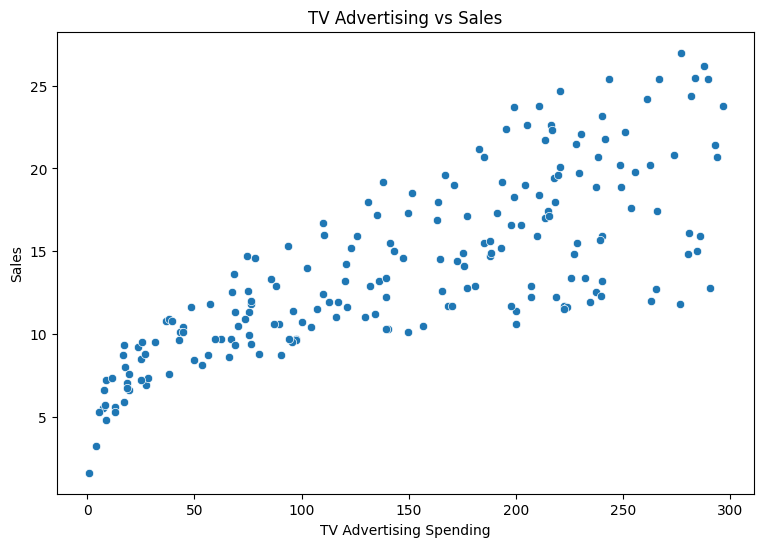

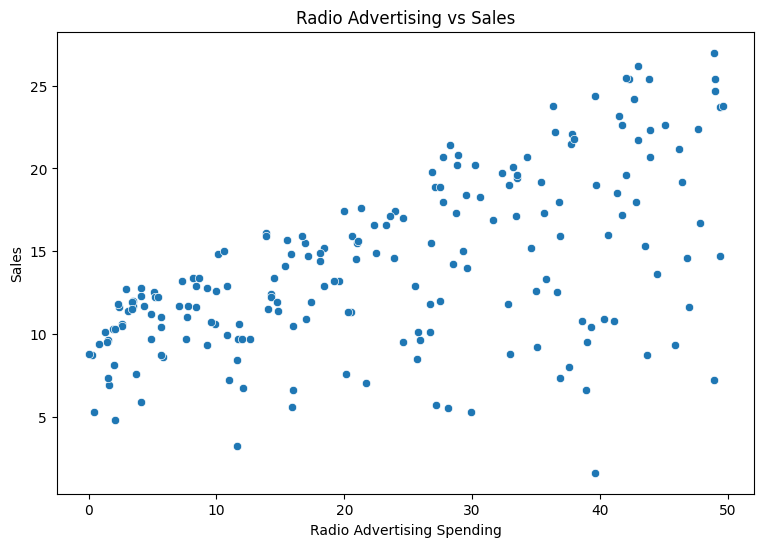

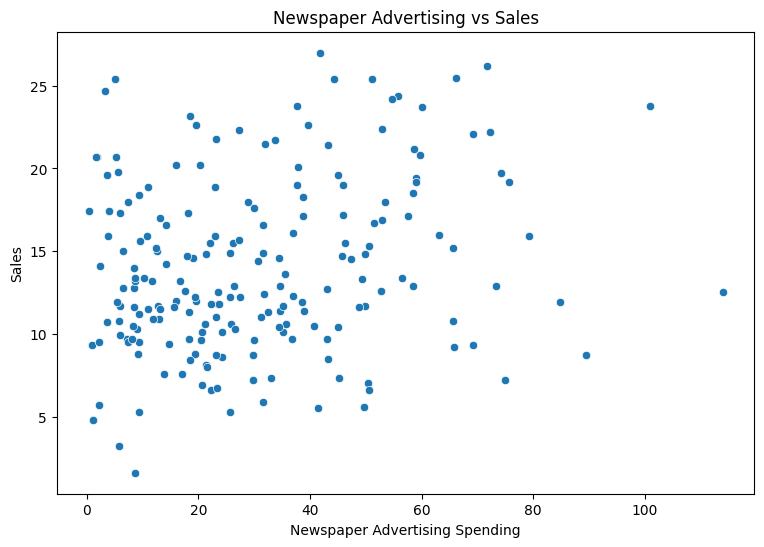


Correlation Matrix:


,unnamed: 0,tv,radio,newspaper,sales
unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
tv,0.017715,1.000000,0.054809,0.056648,0.782224
radio,-0.110680,0.054809,1.000000,0.354104,0.576223
newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
sales,-0.051616,0.782224,0.576223,0.228299,1.000000


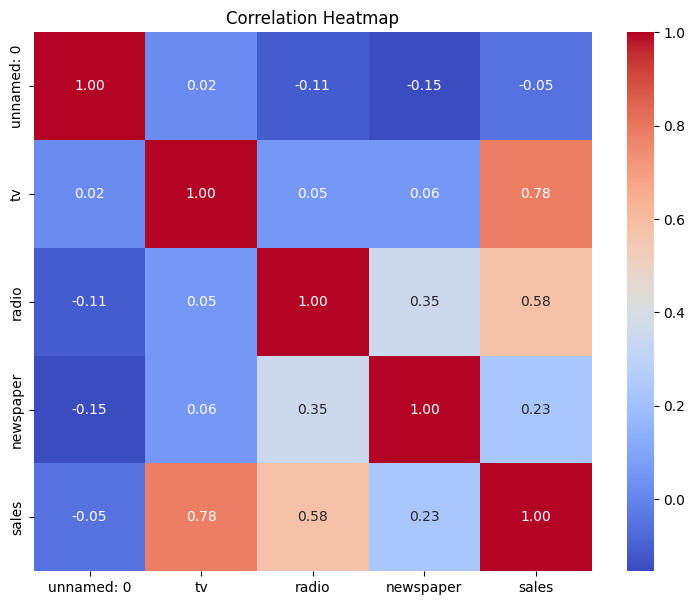


Correlation with Sales:
sales         1.000000
tv            0.782224
radio         0.576223
newspaper     0.228299
unnamed: 0   -0.051616
Name: sales, dtype: float64

Strongest advertising channel: TV
Correlation value: 0.7822244248616067

Features:
['tv', 'radio', 'newspaper']

Target:
sales

Training samples: 160
Testing samples: 40

LINEAR REGRESSION
Linear Regression training completed!

RANDOM FOREST REGRESSOR
Random Forest training completed!

------------------------------------------------------------
Linear Regression
------------------------------------------------------------
MAE  : 1.4608
RMSE : 1.7816
R²   : 0.8994

------------------------------------------------------------
Random Forest Regressor
------------------------------------------------------------
MAE  : 0.6287
RMSE : 0.7572
R²   : 0.9818

MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest Regressor,0.628713,0.757235,0.981833



Best Performing Model: Random Forest Regressor


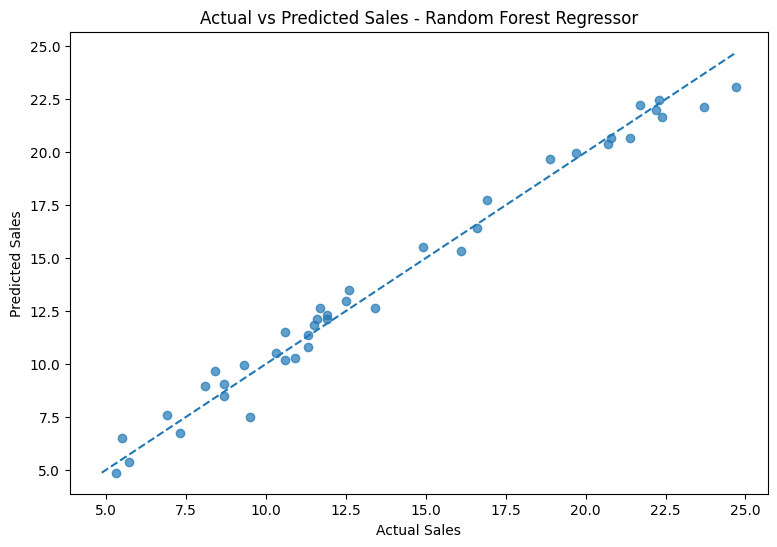

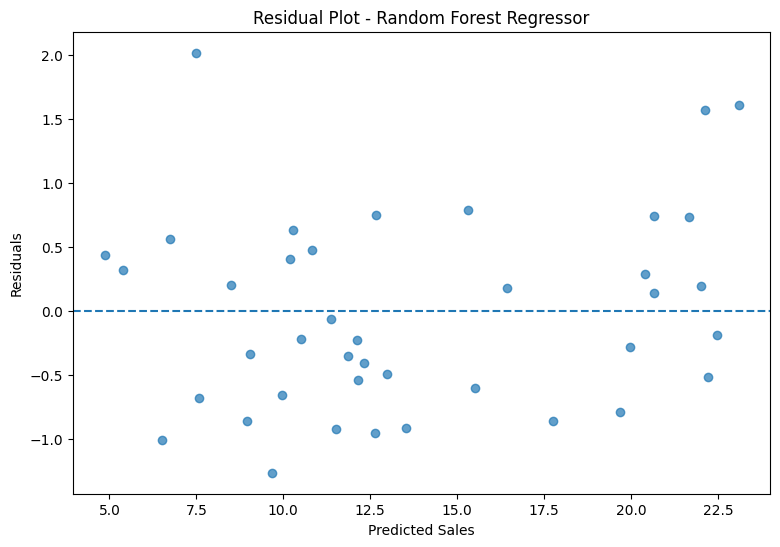

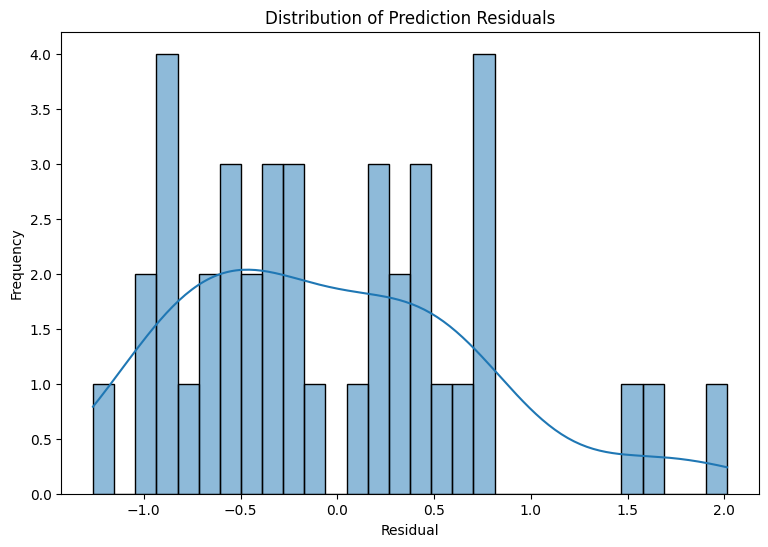


Feature Importance:


,Feature,Importance
0,tv,0.624727
1,radio,0.362119
2,newspaper,0.013153


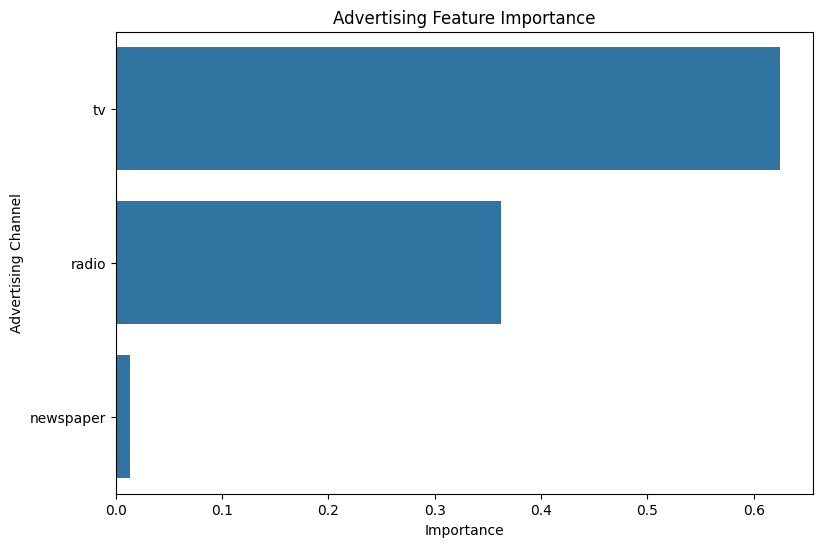


Sample Predictions:


,Actual Sales,Predicted Sales
0,16.9,17.7615
1,22.4,21.6665
2,21.4,20.6595
3,7.3,6.7395
4,24.7,23.0960
5,12.6,13.5155
6,22.3,22.4860
7,8.4,9.6625
8,11.5,11.8545
9,14.9,15.5040



NEW SALES PREDICTION

Advertising Budget:


,tv,radio,newspaper
0,150,30,20


Predicted Sales: 16.72

FINAL PROJECT RESULTS

Dataset Size: (200, 5)

Best Model: Random Forest Regressor

Linear Regression R²: 0.8994
Random Forest R²: 0.9818

Strongest Advertising Channel: TV
Correlation with Sales: 0.7822


In [ ]:
# ============================================================
# OASIS INFOBYTE - DATA SCIENCE INTERNSHIP
# TASK 5 - SALES PREDICTION USING MACHINE LEARNING
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("OASIS INFOBYTE - TASK 5")
print("SALES PREDICTION USING MACHINE LEARNING")
print("=" * 70)


# ============================================================
# 2. LOAD DATASET FROM ZIP
# ============================================================

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, "r") as z:

    # Display files inside ZIP
    print("\nFiles inside ZIP:")
    print(z.namelist())

    # Load Advertising.csv
    df = pd.read_csv(
        z.open("Advertising.csv")
    )


print("\nDataset loaded successfully!")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")

display(df.head())


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

print("\nColumn Names:")

print(df.columns.tolist())


# ============================================================
# 4. INITIAL DATA INSPECTION
# ============================================================

print("\n" + "=" * 70)
print("DATA INFORMATION")
print("=" * 70)

print("\nDataset Information:")

df.info()

print("\nMissing Values:")

print(df.isnull().sum())

print("\nDuplicate Rows:")

print(df.duplicated().sum())

print("\nStatistical Summary:")

display(df.describe())


# ============================================================
# 5. REMOVE DUPLICATES
# ============================================================

duplicate_count = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

print("\nDuplicates removed:", duplicate_count)

print("Dataset shape after cleaning:", df.shape)


# ============================================================
# 6. CHECK DATA TYPES
# ============================================================

print("\nData Types:")

print(df.dtypes)


# ============================================================
# 7. EXPLORATORY DATA ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)


# ============================================================
# 7.1 TV ADVERTISING VS SALES
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tv",
    y="sales"
)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Spending")
plt.ylabel("Sales")

plt.show()


# ============================================================
# 7.2 RADIO ADVERTISING VS SALES
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="radio",
    y="sales"
)

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Spending")
plt.ylabel("Sales")

plt.show()


# ============================================================
# 7.3 NEWSPAPER ADVERTISING VS SALES
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="newspaper",
    y="sales"
)

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Spending")
plt.ylabel("Sales")

plt.show()


# ============================================================
# 8. CORRELATION MATRIX
# ============================================================

correlation = df.corr()

print("\nCorrelation Matrix:")

display(correlation)


# ============================================================
# 9. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


# ============================================================
# 10. CORRELATION WITH SALES
# ============================================================

sales_correlation = (
    correlation["sales"]
    .sort_values(
        ascending=False
    )
)

print("\nCorrelation with Sales:")

print(sales_correlation)


# ============================================================
# 11. FIND STRONGEST ADVERTISING CHANNEL
# ============================================================

channels = [
    "tv",
    "radio",
    "newspaper"
]

channel_correlation = (
    correlation
    .loc[channels, "sales"]
    .abs()
    .sort_values(
        ascending=False
    )
)

strongest_channel = (
    channel_correlation.index[0]
)

print(
    "\nStrongest advertising channel:",
    strongest_channel.upper()
)

print(
    "Correlation value:",
    correlation.loc[
        strongest_channel,
        "sales"
    ]
)


# ============================================================
# 12. PREPARE FEATURES AND TARGET
# ============================================================

X = df[
    [
        "tv",
        "radio",
        "newspaper"
    ]
]

y = df["sales"]


print("\nFeatures:")

print(X.columns.tolist())

print("\nTarget:")

print("sales")


# ============================================================
# 13. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))

print("Testing samples:", len(X_test))


# ============================================================
# 14. MODEL 1 - LINEAR REGRESSION
# ============================================================

print("\n" + "=" * 70)
print("LINEAR REGRESSION")
print("=" * 70)

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = (
    linear_model.predict(
        X_test
    )
)

print("Linear Regression training completed!")


# ============================================================
# 15. MODEL 2 - RANDOM FOREST REGRESSOR
# ============================================================

print("\n" + "=" * 70)
print("RANDOM FOREST REGRESSOR")
print("=" * 70)

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = (
    random_forest_model.predict(
        X_test
    )
)

print("Random Forest training completed!")


# ============================================================
# 16. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model_name,
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    print("\n" + "-" * 60)

    print(model_name)

    print("-" * 60)

    print(
        f"MAE  : {mae:.4f}"
    )

    print(
        f"RMSE : {rmse:.4f}"
    )

    print(
        f"R²   : {r2:.4f}"
    )

    return mae, rmse, r2


# ============================================================
# 17. EVALUATE LINEAR REGRESSION
# ============================================================

linear_mae, linear_rmse, linear_r2 = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)


# ============================================================
# 18. EVALUATE RANDOM FOREST
# ============================================================

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    "Random Forest Regressor",
    y_test,
    random_forest_predictions
)


# ============================================================
# 19. MODEL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "R2 Score": [
        linear_r2,
        rf_r2
    ]

})


print("\n" + "=" * 70)

print("MODEL COMPARISON")

print("=" * 70)

display(comparison)


# ============================================================
# 20. SELECT BEST MODEL
# ============================================================

if linear_r2 >= rf_r2:

    best_model = linear_model

    best_predictions = linear_predictions

    best_model_name = "Linear Regression"

else:

    best_model = random_forest_model

    best_predictions = random_forest_predictions

    best_model_name = "Random Forest Regressor"


print(
    "\nBest Performing Model:",
    best_model_name
)


# ============================================================
# 21. ACTUAL VS PREDICTED SALES
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales - "
    + best_model_name
)

minimum = min(
    y_test.min(),
    best_predictions.min()
)

maximum = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()


# ============================================================
# 22. RESIDUAL ANALYSIS
# ============================================================

residuals = (
    y_test -
    best_predictions
)

plt.figure(figsize=(9, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")

plt.ylabel("Residuals")

plt.title(
    "Residual Plot - "
    + best_model_name
)

plt.show()


# ============================================================
# 23. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Distribution of Prediction Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()


# ============================================================
# 24. FEATURE IMPORTANCE
# ============================================================

if best_model_name == "Random Forest Regressor":

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance":
        random_forest_model.feature_importances_

    })

else:

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance":
        np.abs(
            linear_model.coef_
        )

    })


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


print("\nFeature Importance:")

display(importance)


# ============================================================
# 25. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Advertising Feature Importance"
)

plt.xlabel("Importance")

plt.ylabel("Advertising Channel")

plt.show()


# ============================================================
# 26. SAMPLE PREDICTIONS
# ============================================================

sample_predictions = pd.DataFrame({

    "Actual Sales":
    y_test.values[:10],

    "Predicted Sales":
    best_predictions[:10]

})


print("\nSample Predictions:")

display(sample_predictions)


# ============================================================
# 27. PREDICT SALES FOR NEW ADVERTISING BUDGET
# ============================================================

new_advertising = pd.DataFrame({

    "tv": [150],

    "radio": [30],

    "newspaper": [20]

})

predicted_sales = (
    best_model.predict(
        new_advertising
    )
)


print("\n" + "=" * 70)

print("NEW SALES PREDICTION")

print("=" * 70)

print("\nAdvertising Budget:")

display(new_advertising)

print(
    f"Predicted Sales: "
    f"{predicted_sales[0]:.2f}"
)


# ============================================================
# 28. FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)

print("FINAL PROJECT RESULTS")

print("=" * 70)

print(
    "\nDataset Size:",
    df.shape
)

print(
    "\nBest Model:",
    best_model_name
)

print(
    "\nLinear Regression R²:",
    round(linear_r2, 4)
)

print(
    "Random Forest R²:",
    round(rf_r2, 4)
)

print(
    "\nStrongest Advertising Channel:",
    strongest_channel.upper()
)

print(
    "Correlation with Sales:",
    round(
        correlation.loc[
            strongest_channel,
            "sales"
        ],
        4
    )
)